}
## Pricing Decision Problem

While being the lowest priced seller significantly increases Buy Box ownership (~54pp), lowering price also reduces margin per unit.

The key question is:

What price should a seller set to maximize expected profit, balancing:
- higher Buy Box probability at lower prices
- higher margin at higher prices

This requires combining demand (Buy Box probability) with unit economics

```
Expected Profit = P(Win Buy Box) × Units × Margin per Unit
```

In [1]:
import pandas as pd 
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import statsmodels.api as sm 
import pickle
from src.utils.io import save_df



# load data into dataframe
df = pd.read_csv("data/processed/marketplace_modeling_dataset.csv")

print(df.head())
#PROJECT_ROOT = Path.cwd().resolve()
#print("Project root:", PROJECT_ROOT)

# load buy_box_model results (notebook4) from processed data folder
with open('data/processed/buy_box_model.pkl', 'rb') as f:
    results = pickle.load(f)

   day   asin seller_id  seller_rating fulfillment_type  shipping_days  \
0    1  A0001      S032           88.5              FBA              2   
1    1  A0001      S028           92.1              FBM              5   
2    1  A0001      S018           86.2              FBM              3   
3    1  A0001      S021           91.8              FBA              2   
4    1  A0001      S012           93.1              FBA              2   

   product_cost  target_price  base_demand   price  ...  units_sold  revenue  \
0         82.06        120.02           40  113.24  ...           3   339.72   
1         82.06        120.02           40  113.80  ...          39  4438.20   
2         82.06        120.02           40  115.80  ...           2   231.60   
3         82.06        120.02           40  115.87  ...           4   463.48   
4         82.06        120.02           40  118.65  ...           0     0.00   

   amazon_referral_fee  fulfillment_cost  contribution_profit_per_unit  \


In [3]:
# Probability of winning  

df['p_win'] = results.predict(sm.add_constant(df[[
    'price_gap_to_lowest',
    'shipping_days',
    'seller_rating',
    'is_fba'
]]))

In [4]:
# Avg. Units sold conditioned on winning  

units_if_win = 22
units_if_lose = 1  

df['expected_units'] = (
    df['p_win'] * units_if_win +
    (1 - df['p_win']) * units_if_lose
)

In [20]:
# margin per unit  

df['margin'] = df['price'] - df['product_cost']

In [21]:
# Expected profit  

df['expected_profit'] = df['expected_units'] * df['margin']

### Simulate pricing decisions  

```What happens if I change price relative to competitors?```

In [17]:
# create price change scenarios to simulate profit across all choices (curve)
# 21 scenarios from $5 less and $5 more than the lowest price
price_grid = np.linspace(-5,5,21)
features = ['price_gap_to_lowest','shipping_days','seller_rating','is_fba']

In [43]:
simulation_results = []  

for d in price_grid:
    df_sim = df.copy()

    df_sim['price_gap_to_lowest'] = d 
    
    X_sim = sm.add_constant(df_sim[[
        'price_gap_to_lowest',
        'shipping_days',
        'seller_rating',
        'is_fba'
    ]],
    has_constant='add') # 4 features + 1 intercept

    df_sim['p_win'] = results.predict(X_sim)  

    df_sim['expected_units'] = (
        df_sim['p_win'] * units_if_win +
        (1-df_sim['p_win']) * units_if_lose
    )

    df_sim['sim_price'] = df_sim['lowest_price'] + d  

    df_sim['sim_price'] = df_sim['sim_price'].clip(lower=df_sim['product_cost']*1.05) #sets margin floor at 5%, otherwise demand explodes

    df_sim['sim_referral_fee'] = 0.15 * df_sim['sim_price'] # Amazon marketplace commission

    df_sim['sim_margin'] = (
        df_sim['sim_price']
        - df_sim['product_cost']
        - df_sim['sim_referral_fee']
        - df_sim['fulfillment_cost']
    )

    df_sim['expected_profit'] = (
        df_sim['expected_units'] * df_sim['sim_margin']
    )

    simulation_results.append({
        'price_delta': d, 
        'avg_profit': df_sim['expected_profit'].mean(),
        'avg_p_win': df_sim['p_win'].mean(),
        "avg_margin": df_sim['sim_margin'].mean()
    })

sim_df = pd.DataFrame(simulation_results)

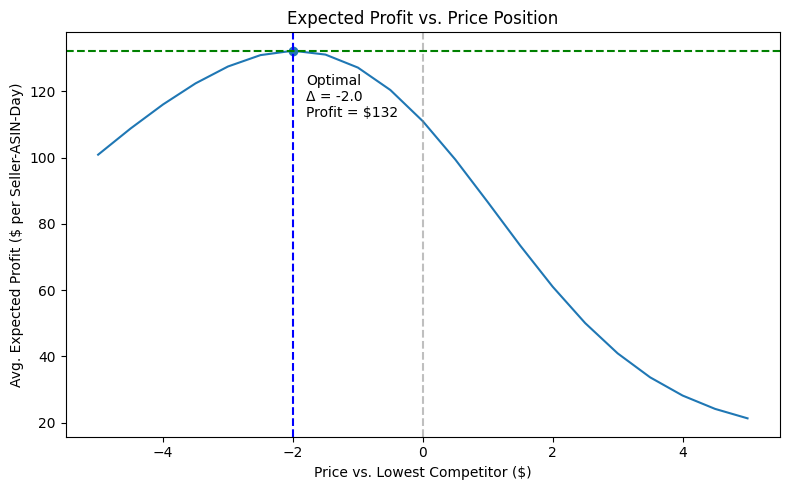

In [55]:
plt.figure(figsize=(8,5))

plt.plot(sim_df['price_delta'], sim_df['avg_profit'])

plt.axvline(0, linestyle = '--', color='grey', alpha=0.5)

opt = sim_df.loc[sim_df['avg_profit'].idxmax()]
plt.axvline(opt['price_delta'], linestyle='--', color='blue')
plt.axhline(opt['avg_profit'], linestyle='--', color='green')

plt.scatter(opt['price_delta'], opt['avg_profit'])
plt.text(
    opt['price_delta'] + 0.2,  # slight shift right
    opt['avg_profit'] - 7,
    f"Optimal\nΔ = {opt['price_delta']:.1f}\nProfit = ${opt['avg_profit']:.0f}",
    verticalalignment='top'
)


plt.title("Expected Profit vs. Price Position")
plt.xlabel("Price vs. Lowest Competitor ($)")
plt.ylabel("Avg. Expected Profit ($ per Seller-ASIN-Day)")

plt.tight_layout()
plt.show()

```Each point represents the average expected daily profit for a seller listing a product (ASIN), given a specific pricing position relative to competitors.```  

### Interpretation  

```"If a seller lists a product and prices it about $2 below the lowest competitor, they can expect to earn approximately $120–$130 per day on average, assuming similar marketplace conditions (shipping speed, rating, FBA status, etc.)."```  

Your dataset includes variation in:  

	•	shipping_days  
	•	seller_rating  
	•	FBA vs non-FBA  
	•	competition context  

In [32]:
sim_df.loc[sim_df["avg_profit"].idxmax()]

price_delta     -2.000000
avg_profit     132.231629
avg_p_win        0.816098
avg_margin       7.211401
Name: 6, dtype: float64

```The optimal pricing point occurs at approximately $2 below the lowest competitor, where the seller achieves an ~82% Buy Box win probability while maintaining a positive margin of ~$7 per unit. This balance between conversion and margin maximizes expected profit.```  

Sanity Check  

    - avg_p_win = 0.82  
    - avg_margin = $7.2  

    - Expected Units = (0.82 * 22) + (0.18 x 1) = 18 units  
         (probability of winning (82%) x avg. units sold when winning buy box) + (1-probability of winning(18%) x avg. units sold when not winning buy box)**  

    - Expected Profit = 18 x 7.20 = $130  
            Expected Units (18) x Avg. Margin ($7.20)

### FBA vs. Non-FBA Simualtion

In [57]:
simulation_results = []

for d in price_grid:
    
    df_sim = df.copy()
    df_sim["price_gap_to_lowest"] = d

    X_sim = sm.add_constant(
        df_sim[[
            "price_gap_to_lowest",
            "shipping_days",
            "seller_rating",
            "is_fba"
        ]],
        has_constant="add"
    )

    df_sim["p_win"] = results.predict(X_sim)

    df_sim["expected_units"] = (
        df_sim["p_win"] * units_if_win +
        (1 - df_sim["p_win"]) * units_if_lose
    )

    df_sim["sim_price"] = df_sim["lowest_price"] + d
    df_sim["sim_price"] = df_sim["sim_price"].clip(lower=df_sim["product_cost"] * 1.05)

    df_sim["sim_referral_fee"] = 0.15 * df_sim["sim_price"]

    df_sim["sim_margin"] = (
        df_sim["sim_price"]
        - df_sim["product_cost"]
        - df_sim["sim_referral_fee"]
        - df_sim["fulfillment_cost"]
    )

    df_sim["expected_profit"] = df_sim["expected_units"] * df_sim["sim_margin"]

    # split results
    for fba_flag in [0, 1]:
        subset = df_sim[df_sim["is_fba"] == fba_flag]

        simulation_results.append({
            "price_delta": d,
            "is_fba": fba_flag,
            "avg_profit": subset["expected_profit"].mean()
        })

sim_df = pd.DataFrame(simulation_results)

In [59]:
opt_df = sim_df.loc[
    sim_df.groupby('is_fba')['avg_profit'].idxmax()
]

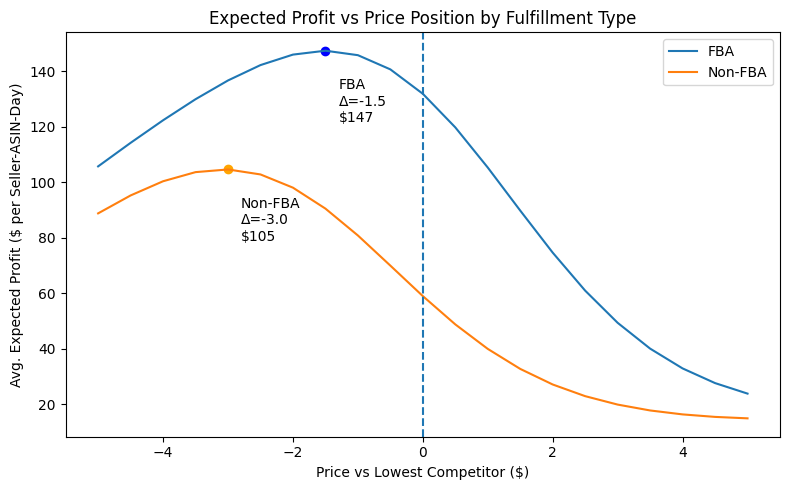

In [64]:

plt.figure(figsize=(8,5))

# plot curves
for fba_flag, label in [(1, "FBA"), (0, "Non-FBA")]:
    subset = sim_df[sim_df["is_fba"] == fba_flag]
    plt.plot(subset["price_delta"], subset["avg_profit"], label=label)

# baseline
plt.axvline(0, linestyle='--')

# annotate each optimal point
for _, row in opt_df.iterrows():
    
    if row['is_fba'] == 1:
        label = 'FBA'
        color='blue'
    else:
        label = "Non-FBA"
        color = 'orange'
    
    # dot
    plt.scatter(row["price_delta"], row["avg_profit"], color=color)
    
    # text slightly below/right of point
    plt.text(
        row["price_delta"] + 0.2,
        row["avg_profit"] - 10,
        f"{label}\nΔ={row['price_delta']:.1f}\n${row['avg_profit']:.0f}",
        va='top'
    )

plt.title("Expected Profit vs Price Position by Fulfillment Type")
plt.xlabel("Price vs Lowest Competitor ($)")
plt.ylabel("Avg. Expected Profit ($ per Seller-ASIN-Day)")
plt.legend()

plt.tight_layout()
plt.show()

## Fulfillment Cost Considerations

The analysis incorporates fulfillment costs at a per-unit level, capturing the higher operational cost associated with FBA relative to non-FBA sellers.

However, the model simplifies the full cost structure of Amazon fulfillment. In practice, FBA includes additional costs such as storage fees, inbound logistics, and inventory holding risk.

Despite this simplification, the results highlight the core tradeoff:

- FBA increases Buy Box competitiveness and demand  
- FBA also increases per-unit cost  

The optimal strategy depends on whether the demand uplift from FBA offsets its higher operational costs.

,price_delta,is_fba,avg_profit
8,-3.0,0,104.619107
15,-1.5,1,147.380144
